In [1]:
import arviz as az
idata = az.from_netcdf("no2_quad.nc")

c:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\.venv\lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
post = idata.posterior

In [6]:
from utils import *

In [16]:
import pandas as pd
import numpy as np
alpha = post["alpha"].values.reshape(-1)
beta1 = post["beta1"].values.reshape(-1)
beta2 = post["beta2"].values.reshape(-1)
# df, max_day = get_data()
# df["day"] *= max_day
df = pd.read_csv("../no2.csv")
df["day"] = df.index + 1
t = df["day"].values   # scaled time if you used scaled t


In [17]:
# shape: (n_draws, n_timepoints)
trend_draws = beta1[:, None] + 2 * beta2[:, None] * t[None, :]


In [18]:
trend_mean = trend_draws.mean(axis=0)
trend_low, trend_high = np.percentile(trend_draws, [2.5, 97.5], axis=0)


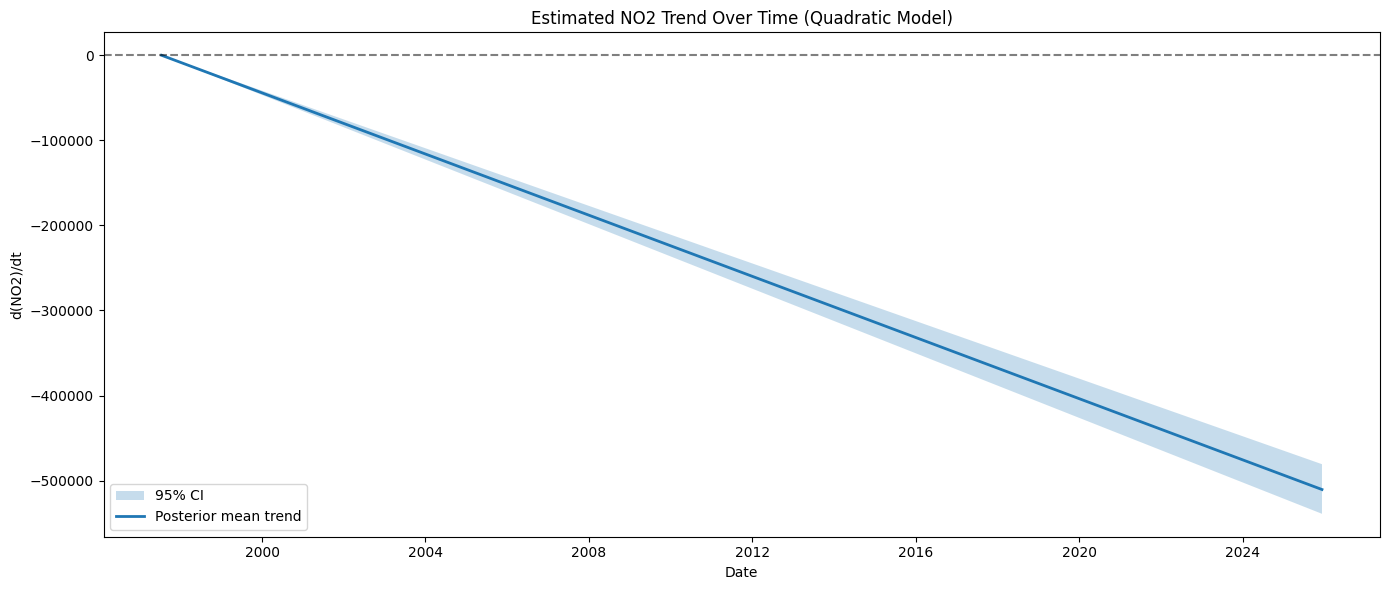

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

start_date = pd.to_datetime("1997-07-17")
dates = start_date + pd.to_timedelta(t - 1, unit="D")

plt.figure(figsize=(14,6))
plt.fill_between(dates, trend_low, trend_high, alpha=0.25, label="95% CI")
plt.plot(dates, trend_mean, lw=2, label="Posterior mean trend")
plt.axhline(0, color="black", ls="--", alpha=0.5)

plt.title("Estimated NO2 Trend Over Time (Quadratic Model)")
plt.ylabel("d(NO2)/dt")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
t0 = t[0]
tT = t[-1]

trend_start = beta1 + 2*beta2*t0
trend_end   = beta1 + 2*beta2*tT

np.mean(trend_start), np.percentile(trend_start, [2.5,97.5])
np.mean(trend_end),   np.percentile(trend_end,   [2.5,97.5])


(np.float64(-510444.8798729403), array([-538971.90625185, -480668.14254993]))

In [21]:
avg_trend = trend_draws.mean(axis=1)   # per draw
avg_trend.mean(), np.percentile(avg_trend, [2.5,97.5])


(np.float64(-255262.80808686625), array([-269527.97019595, -240372.83645852]))

In [34]:
t_vals

0       -1.000000
1       -0.999807
2       -0.999614
3       -0.999422
4       -0.999229
           ...   
10368    0.999229
10369    0.999422
10370    0.999614
10371    0.999807
10372    1.000000
Name: day, Length: 10373, dtype: float64

In [35]:
idata = az.from_netcdf("no2_quad.nc")

# Extract posterior samples
alpha = idata.posterior["alpha"].values.reshape(-1)
beta1 = idata.posterior["beta1"].values.reshape(-1)
beta2 = idata.posterior["beta2"].values.reshape(-1)
df, max_day = get_data()
t_vals = df["day"]
t_start = -1
t_end = 1


In [36]:
mu_start = alpha + beta1 * t_start + beta2 * t_start**2
mu_end   = alpha + beta1 * t_end   + beta2 * t_end**2

avg_trend = (mu_end - mu_start) / (t_end - t_start)


In [37]:
avg_mean = avg_trend.mean()
avg_low, avg_high = np.percentile(avg_trend, [2.5, 97.5])

print(f"Average trend (per day): {avg_mean:.4f}")
print(f"95% CI: [{avg_low:.4f}, {avg_high:.4f}]")


Average trend (per day): -31.5303
95% CI: [-32.5277, -30.5439]


In [39]:
avg_trend_year = avg_trend / 365.25
print(f"Average trend (per year): {avg_trend_year.mean():.2f}")


Average trend (per year): -0.09


In [44]:
idata = az.from_netcdf("no2_quad.nc")

# Extract posterior draws
alpha = idata.posterior["alpha"].values  # (chains, draws)
beta1 = idata.posterior["beta1"].values
beta2 = idata.posterior["beta2"].values

In [48]:
import arviz as az
import numpy as np

# Load posterior
idata = az.from_netcdf("no2_quad.nc")

# Convert posterior draws to NumPy arrays
alpha = idata.posterior["alpha"].values  # shape: (chains, draws)
beta1 = idata.posterior["beta1"].values
beta2 = idata.posterior["beta2"].values

# Use normalized t values (or days)
t_norm = df["day"].values
# Compute pointwise trend: derivative of mu = alpha + beta1*t + beta2*t^2
# dμ/dt_norm = beta1 + 2*beta2*t_norm
# Convert to trend per day: multiply by 1 if t is already in days (or by step if normalized)
dmu_dt_day = (beta1[..., None] + 2*beta2[..., None] * t_norm[None, None, :])  # shape: (chains, draws, n_obs)

# Convert to trend per year
dmu_dt_year = dmu_dt_day * 365

# Summarize pointwise trend (mean and 95% CI)
trend_day_mean = dmu_dt_day.mean(axis=(0,1))
trend_day_low, trend_day_high = np.percentile(dmu_dt_day, [2.5, 97.5], axis=(0,1))

trend_year_mean = dmu_dt_year.mean(axis=(0,1))
trend_year_low, trend_year_high = np.percentile(dmu_dt_year, [2.5, 97.5], axis=(0,1))

# Average trend over all time
avg_trend_day = trend_day_mean.mean()
avg_trend_day_ci = [trend_day_low.mean(), trend_day_high.mean()]

avg_trend_year = trend_year_mean.mean()
avg_trend_year_ci = [trend_year_low.mean(), trend_year_high.mean()]

print("Pointwise trend per day:", trend_day_mean)
print("Pointwise trend per year:", trend_year_mean)
print("Average trend per day:", avg_trend_day, "95% CI:", avg_trend_day_ci)
print("Average trend per year:", avg_trend_year, "95% CI:", avg_trend_year_ci)


Pointwise trend per day: [ 17.67560503  17.6661168   17.65662857 ... -80.71732434 -80.72681256
 -80.73630079]
Pointwise trend per year: [  6451.5958344    6448.132631     6444.66942761 ... -29461.82338238
 -29465.28658578 -29468.74978917]
Average trend per day: -31.530347883250002 95% CI: [np.float64(-33.35978356165495), np.float64(-29.738283232057203)]
Average trend per year: -11508.57697738625 95% CI: [np.float64(-12176.321000004056), np.float64(-10854.47337970088)]


In [51]:
import numpy as np
import arviz as az

# Load idata
idata = az.from_netcdf("no2_quad.nc")

# Flatten posterior draws
beta1 = idata.posterior["beta1"].values.flatten()  # shape (n_draws,)
beta2 = idata.posterior["beta2"].values.flatten()  # shape (n_draws,)

# Your standardized days
t_std = df["day"].values  # shape (n_obs,)
scale = max_day  # scale used when standardizing

# Compute pointwise derivative per day
# Result shape: (n_draws, n_obs)
dmu_dt_day = (beta1[:, None] + 2 * beta2[:, None] * t_std[None, :]) / scale

# Per year
dmu_dt_year = dmu_dt_day * 365

# Summarize
trend_day_mean = dmu_dt_day.mean(axis=0)
trend_day_low, trend_day_high = np.percentile(dmu_dt_day, [2.5, 97.5], axis=0)

trend_year_mean = dmu_dt_year.mean(axis=0)
trend_year_low, trend_year_high = np.percentile(dmu_dt_year, [2.5, 97.5], axis=0)

# Average trend over time
avg_trend_day = trend_day_mean.mean()
avg_trend_day_ci = [trend_day_low.mean(), trend_day_high.mean()]

avg_trend_year = trend_year_mean.mean()
avg_trend_year_ci = [trend_year_low.mean(), trend_year_high.mean()]

print("Average trend per day:", avg_trend_day, "95% CI:", avg_trend_day_ci)
print("Average trend per year:", avg_trend_year, "95% CI:", avg_trend_year_ci)


Average trend per day: -0.006079897393607789 95% CI: [np.float64(-0.006432661697195323), np.float64(-0.005734339227161049)]
Average trend per year: -2.2191625486668434 95% CI: [np.float64(-2.347921519476293), np.float64(-2.093033817913783)]


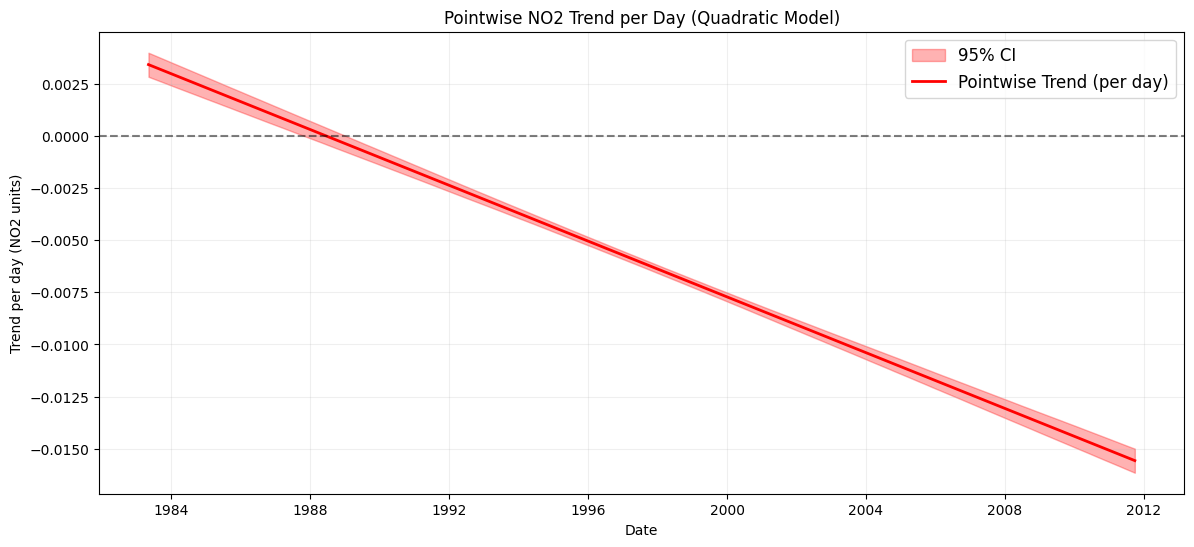

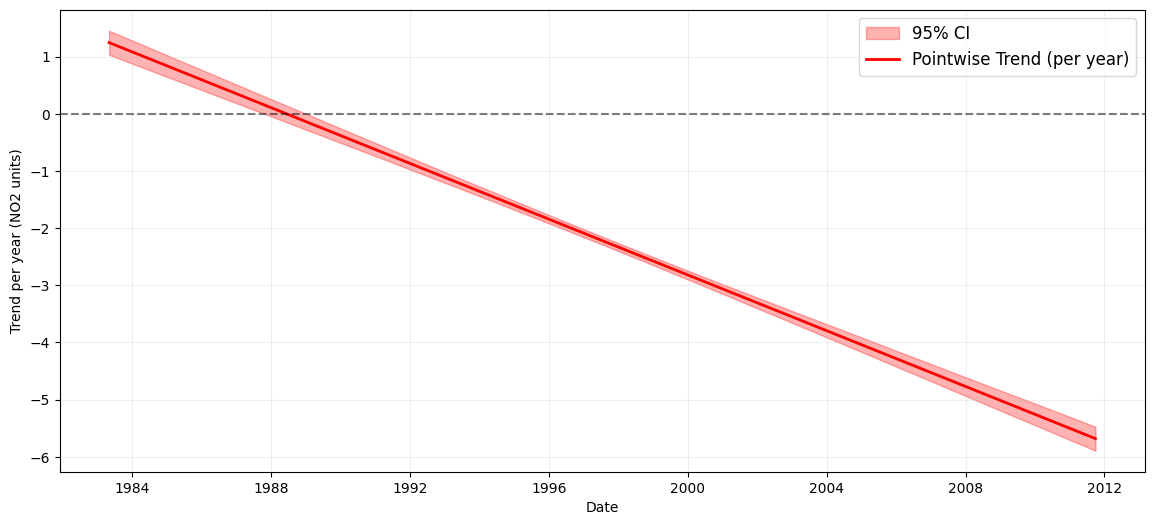

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Your previous calculations ---
# trend_day_mean, trend_day_low, trend_day_high
# trend_year_mean, trend_year_low, trend_year_high
# dates: convert standardized days to actual dates
start_date = pd.to_datetime("1997-07-17")
dates = start_date + pd.to_timedelta(df["day"].values * scale, unit="D")

# --- Plot daily trend ---
plt.figure(figsize=(14, 6))
plt.fill_between(dates, trend_day_low, trend_day_high, color="red", alpha=0.3, label="95% CI")
plt.plot(dates, trend_day_mean, color="red", lw=2, label="Pointwise Trend (per day)")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Trend per day (NO2 units)")
plt.title("Pointwise NO2 Trend per Day (Quadratic Model)")
plt.legend(fontsize=12)
plt.grid(alpha=0.2)
plt.show()

# --- Plot yearly trend ---
plt.figure(figsize=(14, 6))
plt.fill_between(dates, trend_year_low, trend_year_high, color="red", alpha=0.3, label="95% CI")
plt.plot(dates, trend_year_mean, color="red", lw=2, label="Pointwise Trend (per year)")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Trend per year (NO2 units)")
plt.legend(fontsize=12)
plt.grid(alpha=0.2)
plt.show()


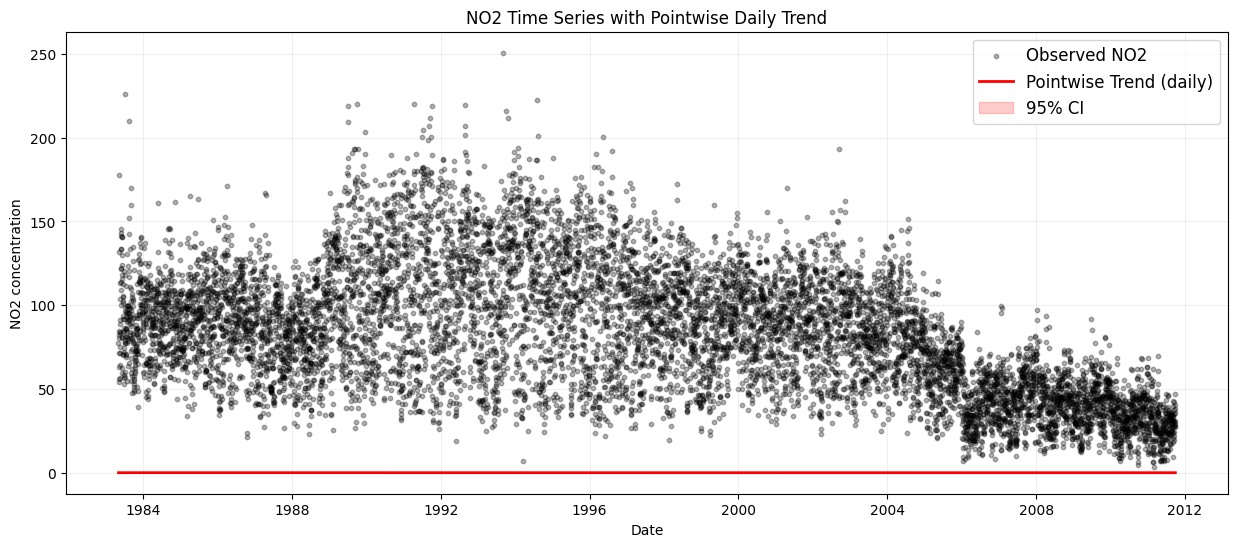

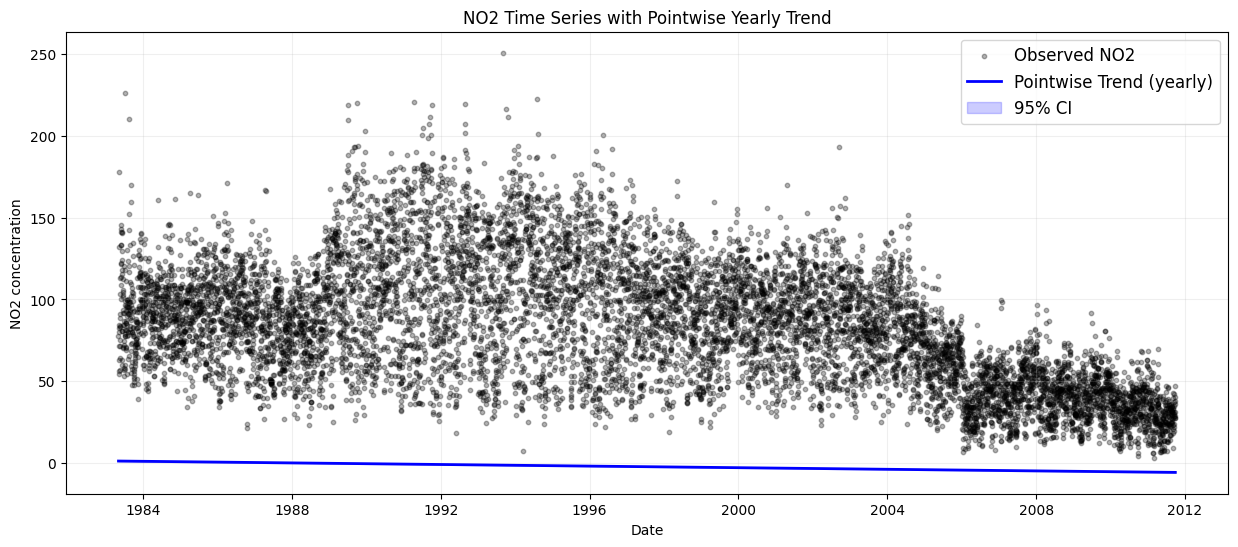

Text(0.5, 1.0, 'Pointwise NO2 Trend per Year (Quadratic Model)')

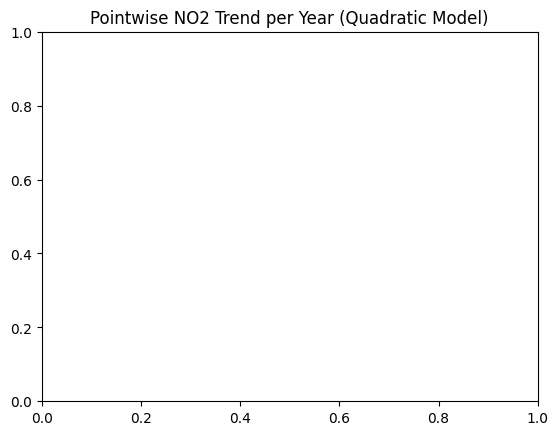

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Convert standardized days to actual dates ---
start_date = pd.to_datetime("1997-07-17")
dates = start_date + pd.to_timedelta(df["day"].values * scale, unit="D")

# --- Plot observed NO2 and pointwise trend (daily) ---
plt.figure(figsize=(15, 6))
plt.scatter(dates, df["no2"], color="black", alpha=0.3, s=10, label="Observed NO2")
plt.plot(dates, trend_day_mean, color="red", lw=2, label="Pointwise Trend (daily)")
plt.fill_between(dates, trend_day_low, trend_day_high, color="red", alpha=0.2, label="95% CI")
plt.xlabel("Date")
plt.ylabel("NO2 concentration")
plt.title("NO2 Time Series with Pointwise Daily Trend")
plt.legend(fontsize=12)
plt.grid(alpha=0.2)
plt.show()

# --- Optional: plot yearly trend overlay ---
plt.figure(figsize=(15, 6))
plt.scatter(dates, df["no2"], color="black", alpha=0.3, s=10, label="Observed NO2")
plt.plot(dates, trend_year_mean, color="blue", lw=2, label="Pointwise Trend (yearly)")
plt.fill_between(dates, trend_year_low, trend_year_high, color="blue", alpha=0.2, label="95% CI")
plt.xlabel("Date")
plt.ylabel("NO2 concentration")
plt.title("NO2 Time Series with Pointwise Yearly Trend")
plt.legend(fontsize=12)
plt.grid(alpha=0.2)
plt.show()
plt.title("Pointwise NO2 Trend per Year (Quadratic Model)")


Average trend per day: -0.0061 (95% CI: -0.0064, -0.0057)
Average trend per year: -2.2192 (95% CI: -2.3479, -2.0930)


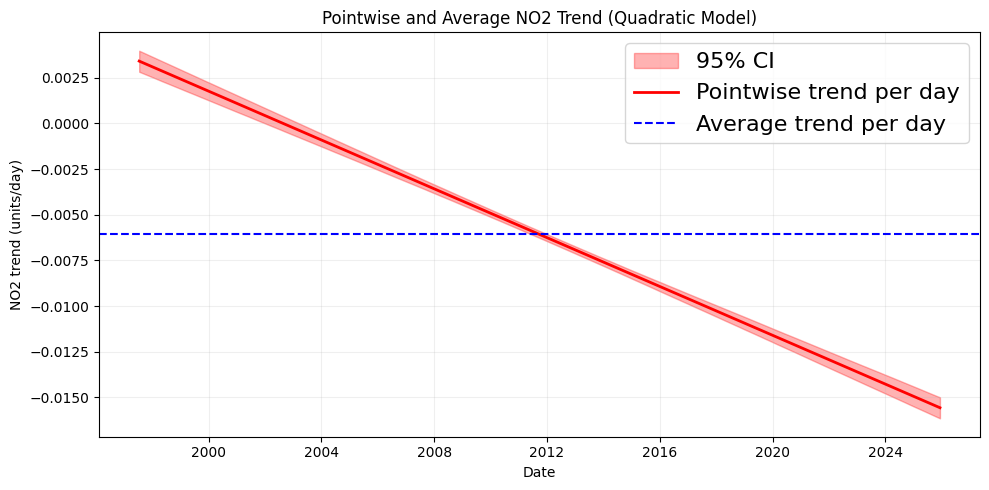

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data and idata ---
df = pd.read_csv("../no2.csv")
df["day"] = df.index + 1

idata = az.from_netcdf("no2_quad.nc")

# Extract posterior draws
alpha = idata.posterior["alpha"].values.reshape(-1)
beta1 = idata.posterior["beta1"].values.reshape(-1)
beta2 = idata.posterior["beta2"].values.reshape(-1)

# Use the same normalization as in get_data()
day_mean = df["day"].mean()
day_centered = df["day"].values - day_mean
scale = np.max(np.abs(day_centered))
t_norm = day_centered / scale  # normalized time used in model

# --- Pointwise derivative (trend) ---
# dμ/dt_norm = beta1 + 2*beta2 * t_norm
# Convert to units per day: divide by scale
dmu_dt_day = (beta1[:, None] + 2 * beta2[:, None] * t_norm[None, :]) / scale

# Convert to per year
dmu_dt_year = dmu_dt_day * 365

# --- Summarize pointwise ---
trend_day_mean = dmu_dt_day.mean(axis=0)
trend_day_low, trend_day_high = np.percentile(dmu_dt_day, [2.5, 97.5], axis=0)

trend_year_mean = dmu_dt_year.mean(axis=0)
trend_year_low, trend_year_high = np.percentile(dmu_dt_year, [2.5, 97.5], axis=0)

# --- Average over all days ---
avg_trend_day = trend_day_mean.mean()
avg_trend_day_ci = [trend_day_low.mean(), trend_day_high.mean()]

avg_trend_year = trend_year_mean.mean()
avg_trend_year_ci = [trend_year_low.mean(), trend_year_high.mean()]

print(f"Average trend per day: {avg_trend_day:.4f} (95% CI: {avg_trend_day_ci[0]:.4f}, {avg_trend_day_ci[1]:.4f})")
print(f"Average trend per year: {avg_trend_year:.4f} (95% CI: {avg_trend_year_ci[0]:.4f}, {avg_trend_year_ci[1]:.4f})")

# --- Plot pointwise trend ---
dates = pd.to_datetime("1997-07-17") + pd.to_timedelta(df["day"] - 1, unit="D")

plt.figure(figsize=(10,5))
plt.fill_between(dates, trend_day_low, trend_day_high, color="red", alpha=0.3, label="95% CI")
plt.plot(dates, trend_day_mean, color="red", lw=2, label="Pointwise trend per day")
plt.axhline(avg_trend_day, color="blue", linestyle="--", label="Average trend per day")
plt.xlabel("Date")
plt.ylabel("NO2 trend (units/day)")
plt.legend(fontsize=16)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
